In [38]:
import h5py
import numpy as np
from astropy import units
from IPython.display import clear_output
import matplotlib.pyplot as plt

In [14]:
data = h5py.File("TNG100-1_subhalosCat.hdf5", 'r')

This function gives a quick overview of how to access data in this file. Afterwards, some functions are written to easily get something, instead of having to recalculate/rewrite it multiple times. Link to units: https://www.tng-project.org/data/docs/specifications/ --> Subfind subhalos (Galaxies)

In [5]:
def probe_data(data):
    print("Data keys: " + str(data.keys()))
    
    print("\nHeader attributes: " + str(list(data["Header"].attrs)))

    box_size = data["Header"].attrs["BoxSize"]
    hubble_param = data["Header"].attrs["HubbleParam"]
    nr_subgroups = data["Header"].attrs["Nsubgroups_Total"]
    redshift = data["Header"].attrs["Redshift"]
    print("Boxsize: " + str(box_size))
    print("Hubble param: " + str(hubble_param))
    print("number of subgroups in total: " + str(nr_subgroups))
    print("Redshift: " + str(redshift))
    print("scaling factor fraction a0/a = 1+z = " + str(1.0 + redshift) + ", small enough to set comoving c=1.0.")

    #config just shows the configuration information, not useful for pure data analysis
    #print("\nConfig: " + str(list(data["Config"].attrs)))

    #parameters shows the parameters of the simulation itself, similar to config
    #print("\nParameters: " + str(list(data["Parameters"].attrs)))

    print("\nSubhalo info: " + str(list(data["Subhalo"])))

    

In [6]:
probe_data(data)

Data keys: <KeysViewHDF5 ['Config', 'Header', 'Parameters', 'Subhalo']>

Header attributes: ['BoxSize', 'HubbleParam', 'Nsubgroups_Total', 'Omega0', 'OmegaLambda', 'Redshift', 'Time']
Boxsize: 75000.0
Hubble param: 0.6774
number of subgroups in total: 4371211
Redshift: 2.220446049250313e-16
scaling factor fraction a0/a = 1+z = 1.0000000000000002, small enough to set comoving c=1.0.

Subhalo info: ['SubhaloBHMass', 'SubhaloBHMdot', 'SubhaloBfldDisk', 'SubhaloBfldHalo', 'SubhaloCM', 'SubhaloFlag', 'SubhaloGasMetalFractions', 'SubhaloGasMetalFractionsHalfRad', 'SubhaloGasMetalFractionsMaxRad', 'SubhaloGasMetalFractionsSfr', 'SubhaloGasMetalFractionsSfrWeighted', 'SubhaloGasMetallicity', 'SubhaloGasMetallicityHalfRad', 'SubhaloGasMetallicityMaxRad', 'SubhaloGasMetallicitySfr', 'SubhaloGasMetallicitySfrWeighted', 'SubhaloGrNr', 'SubhaloHalfmassRad', 'SubhaloHalfmassRadType', 'SubhaloIDMostbound', 'SubhaloLen', 'SubhaloLenType', 'SubhaloMass', 'SubhaloMassInHalfRad', 'SubhaloMassInHalfRadTyp

The below functions contain subhalo wide functions.

In [7]:
#get data functions with correct units
def gethubble(data):
    hubble_param = data["Header"].attrs["HubbleParam"]
    return hubble_param

def getbox_size(data):
    hubble_param = gethubble(data)
    raw_box_size = data["Header"].attrs["BoxSize"]
    box_size = (raw_box_size / hubble_param) * units.kpc
    return box_size

#position of subhalo compared to periodic box. Position is of particle with minimum gravitational potential energy.
def getsubhalo_pos(data):
    hubble_param = gethubble(data)
    raw_subhalo_pos = data["Subhalo"]["SubhaloPos"]                  #is in ckpc/h
    subhalo_pos = (raw_subhalo_pos / hubble_param) * units.kpc
    return subhalo_pos

#cm of each subhalo, determined with all types of particles.
def getsubhalo_cm(data):
    hubble_param = gethubble(data)
    raw_subhalo_cm = data["Subhalo"]["SubhaloCM"]                    #is in ckpc/h
    subhalo_cm = (raw_subhalo_cm / hubble_param) * units.kpc
    return subhalo_cm

#total mass of all particles of subhalo. subhalo's of a subhalo not included in mass.
def getsubhalo_mass(data):
    hubble_param = gethubble(data)
    raw_subhalo_mass = data["Subhalo"]["SubhaloMass"]                #is in 10**10 solmass/h
    subhalo_mass = (raw_subhalo_mass*1e10/hubble_param) * units.Msun
    return subhalo_mass

#total mass of subhalo by particle type. 
def getsubhalo_massbytype(data):
    hubble_param = gethubble(data)
    raw_subhalo_massbytype = np.array(data["Subhalo"]["SubhaloMassType"])      #is in 10**10 solmass/h
    subhalo_massbytype = (raw_subhalo_massbytype*1e10/hubble_param) * units.Msun
    #Nx6, [Gas, DM, UNUSED, Tracers, Stars/wind particles, Black holes]
    return subhalo_massbytype

The below functions are necessary for galaxy analysis. As is stated in the assignment: "Each subhalo
with non-zero stellar mass is perceived as the host of an individual galaxy"

In [8]:
#boolean numpy array stating if a subhalo at that index contains a galaxy. 
def getgalaxy_mask(data):
    total_mass = getsubhalo_massbytype(data)
    stellar_mass = total_mass[:,4]

    mask = (stellar_mass > 0.0)
    return mask

def getgalaxy_cm(data):
    galaxy_mask = getgalaxy_mask(data)
    subhalo_cm = getsubhalo_cm(data)
    galaxy_cm = subhalo_cm[galaxy_mask, :]
    return galaxy_cm
    

We assume a uniform distribution of galaxies inside the periodic box. So, no random distributions will be taken. 

In [84]:
galaxy_cm = getgalaxy_cm(data)
print("number of galaxies: " + str(len(galaxy_cm)) + r", so O(N^2) will take a while for calculating distances.")

number of galaxies: 337261, so O(N^2) will take a while for calculating distances.


Theory two point correlation with natural estimator: https://arxiv.org/pdf/astro-ph/9912088

DD(bin) is the amount of galaxies with a distance that is constrained by the bin (bin_min, bin_max). This is normalized by dividing by the total combination of galaxy distances N(N-1).

RR(bin) is the expected amount of galaxies with a distance that is constrained by the bin (bin_min, bin_max). This is determined by calculating the density over the entire box and, from this, calculate how many galaxies would be inside the volume constrained by the bin.

In [91]:
def distance(pos1, pos2):
    distance = np.linalg.norm(pos1 - pos2)
    return distance

def minimal_distance(pos1, pos2, boxsize):
    displacement = pos1 - pos2
    #see minimal image convention
    displacement -= boxsize*np.round(displacement / boxsize)
    return np.linalg.norm(displacement, axis=1)

#source: https://stackoverflow.com/questions/11339210/how-to-get-integer-values-from-a-string-in-python
def getint_from_string(string):
    integer = int(''.join(filter(str.isdigit, string)))
    return integer
 
def calcDD(data, nr_bins=100, binmode="linear"):
    galaxy_cm = getgalaxy_cm(data)
    nr_galaxies = len(galaxy_cm)
    boxsize = getbox_size(data)

    #nr_bins-1, because bins are the bin_edges
    DD = np.zeros(nr_bins-1)
    
    bins = np.linspace(0.0, boxsize/2, nr_bins)
    if(binmode == "logarithmic"):
        bins = np.logspace(np.log10(0.0), np.log10(boxsize.value/2), nr_bins) * boxsize.unit

    for i in range(nr_galaxies):
        print(f"Bins are {binmode}, Progress: {i/(nr_galaxies-1)*100:.2f}%")
        clear_output(wait=True) 
        
        galaxy_i = galaxy_cm[i]
        galaxies_i = np.empty([nr_galaxies-1, galaxy_i.shape[0]])*units.kpc
        galaxies_i[:] = galaxy_i
        galaxies_other = np.delete(galaxy_cm, i, 0)
        
        dist = minimal_distance(galaxies_i, galaxies_other, boxsize)
        hist, bins = np.histogram(dist, bins=bins)
        DD += hist

    #all galaxy distances were double counted for ease of programming, simply divide by two
    DD = DD/2
    DD_filename = "DD_" + str(nr_bins) + "bins_" + binmode
    print("done")
    print("Filename: " + DD_filename)
    print("DD: " + str(DD))
    np.save(DD_filename, DD)

#https://arxiv.org/pdf/astro-ph/9912088
def two_point_correlation(data, DD_filename):
    nr_bins = getint_from_string(DD_filename)
    galaxy_cm = getgalaxy_cm(data)
    nr_galaxies = len(galaxy_cm)
    boxsize = getbox_size(data)

    DD_unnormalized = np.load(DD_filename)
    DD = DD_unnormalized / (sum(DD_unnormalized))
    print("sum DD: " + str(sum(DD)))

    bins = np.linspace(0.0, boxsize/2, nr_bins)
    if "logarithmic" in DD_filename:
        bins = np.logspace(np.log10(0.0), np.log10(boxsize.value/2), nr_bins) * boxsize.unit

    #-----------------------------CALCULATE RR------------------------------------------
    #RR(r)=ρ4πr2dr, dr = bin width, r=middle of bin
    boxvolume = boxsize**3
    galaxies_per_volume = nr_galaxies/boxvolume

    bin_inner_bound = bins[:-1]         
    bin_outer_bound = bins[1:]       
    bin_centre = (bin_inner_bound + bin_outer_bound) / 2  

    dr = bin_outer_bound - bin_inner_bound
    bin_volume = 4*np.pi*(bin_centre**2)*dr

    #this is from the point of view of 1 galaxy at r=0, what is the probability of it having a pair with another galaxy in a bin?
    # nr_point_pairs: n(n-1)/2
    nr_point_pairs = nr_galaxies*(nr_galaxies-1)/2
    expected_pairs_per_bin = bin_volume*galaxies_per_volume
    RR = (expected_pairs_per_bin/nr_point_pairs)*nr_galaxies
    #sum of RR is almost 1, but correct the floating point error
    RR = RR/sum(RR)
    print("RR sum: " + str(sum(RR)))

    two_point_correlation = DD/RR - 1.0
    return two_point_correlation, bin_centre
        

In [ ]:
calcDD(data, nr_bins=100, binmode="logarithmic")

Bins are logarithmic, Progress: 2.57%


In [82]:
def plot_two_point_correlation(data, DD_filename="DD_100bins_linear.npy"):
    boxsize = getbox_size(data)
    half_boxsize = boxsize.to("Mpc")/2
    
    two_point_corr, bin_center = two_point_correlation(data=data, DD_filename=DD_filename)
    plt.scatter(bin_center.to("Mpc"), two_point_corr, s=2, c="blue", label="Data")
    plt.plot(bin_center.to("Mpc"), (35*bin_center.to("Mpc")**(-1.8)), c="red", label="r^-1.8", alpha=0.6)
    plt.axvline(x = half_boxsize.value, color = 'green', label = "Half periodic box")

    plt.title("Two point correlation function of simulated galaxies")
    plt.yscale("log")
    plt.xscale("log")
    plt.xlabel("R (" + str(bin_center.to("Mpc").unit) + ")")
    plt.legend()
    plt.show()

sum DD: 1.0
RR sum: 1.0000000000000002


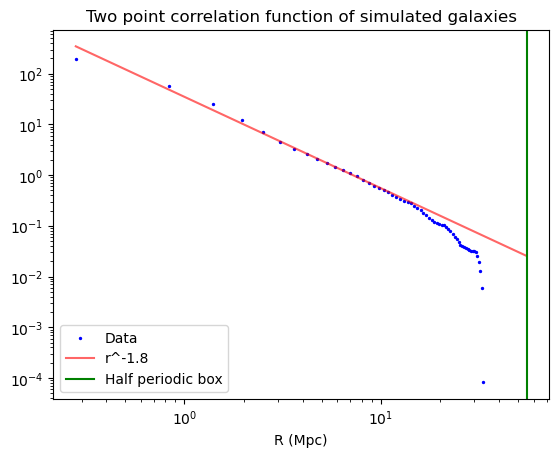

In [83]:
plot_two_point_correlation(data)